# RE LAT - Danggeun: D1/D3/D7 Retention by OS

Compare post-re-engagement retention across iOS vs Android for Danggeun (Karrot) RE campaigns, using **MTID** as the user identifier.

MTID provides coverage for iOS LAT/ATT-opted-out users who lack IDFA.

---

### Table of Contents
- [Step 0: Config](#step-0)
- [Step 1: Campaign Discovery](#step-1)
- [Step 2: Retention Data Pull](#step-2)
- [Step 3: Overall Retention by OS](#step-3)
- [Step 4: Retention Curve D0–D7](#step-4)
- [Step 5: Cohort Trend (Weekly)](#step-5)
- [Step 6: Event Breakdown](#step-6)
- [Step 7: Summary & Insights](#step-7)

In [31]:
#@title Step 0: Environment & Config {display-mode: "form"}

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
sns.set_style('whitegrid')

OS_COLORS = {'IOS': '#007AFF', 'ANDROID': '#3DDC84', 'ios': '#007AFF', 'android': '#3DDC84'}

client = bigquery.Client(project='moloco-ods')

def process_query(query):
    return client.query(query).result().to_dataframe()

print('Environment ready.')

Environment ready.


In [37]:
#@title Step 0: Configuration  <a id='step-0'></a>

# START_DATE AND END_DATE are applied to the impression time, not the cv timestamp.
START_DATE = '2026-01-01'
END_DATE   = '2026-02-01'

ADVERTISER_ID = 'Voql38wJkmDNzXbW'

# If you already know specific campaign IDs, list them here to skip discovery
KNOWN_CAMPAIGN_IDS = [
    # 'JCbqtZCd2NehCzLL',  # example from iOS RE LAT coverage query
]

# Retention days to measure
RETENTION_DAYS = [1, 3, 7, 14, 30]

print(f'Date range: {START_DATE} → {END_DATE}')
print(f'Advertiser ID: {ADVERTISER_ID}')
print(f'Retention checkpoints: D{"  D".join(str(d) for d in RETENTION_DAYS)}')

Date range: 2026-01-01 → 2026-02-01
Advertiser ID: Voql38wJkmDNzXbW
Retention checkpoints: D1  D3  D7  D14  D30


---
## Step 1: Campaign Discovery <a id='step-1'></a>

Identify Danggeun RE campaigns from `campaign_digest` × `product_digest`, grouped by OS.

In [38]:
#@title Step 1: Discover Danggeun RE campaigns

query_campaigns = f'''
SELECT
  cd.campaign_id,
  cd.campaign_title,
  cd.campaign_os AS os,
  cd.product_id,
  pd.tracking_bundle,
  cd.campaign_goal,
  cd.is_archived,
  JSON_VALUE(cd.original_json, '$.disabled') AS disabled
FROM `focal-elf-631.standard_digest.campaign_digest` cd
JOIN `focal-elf-631.standard_digest.product_digest` pd
  ON cd.product_id = pd.product_id
WHERE cd.campaign_type = 'APP_REENGAGEMENT'
  AND cd.advertiser_id = '{ADVERTISER_ID}'
  AND cd.is_archived = FALSE
  AND JSON_VALUE(cd.original_json, '$.disabled') = 'false'
ORDER BY cd.campaign_os, cd.campaign_title
'''

df_campaigns = process_query(query_campaigns)
print(f'Found {len(df_campaigns)} RE campaigns')
print(f'\nBy OS:')
print(df_campaigns.groupby('os').agg(
    n_campaigns=('campaign_id', 'nunique'),
    bundles=('tracking_bundle', lambda x: ', '.join(x.unique()))
))
print()
df_campaigns[['campaign_id', 'campaign_title', 'os', 'tracking_bundle', 'campaign_goal']]

Found 6 RE campaigns

By OS:
         n_campaigns           bundles
os                                    
ANDROID            5  com.towneers.www
IOS                1      id1018769995



,campaign_id,campaign_title,os,tracking_bundle,campaign_goal
0,naLfOc4evDfMS29y,KR_RE_LocalAds_AEO_CreateAd_AOS,ANDROID,com.towneers.www,OPTIMIZE_CPA_FOR_APP_RE
1,a9jBukYkyAH3pIMg,KR_RE_LocalAds_AEO_CreateBP_AOS,ANDROID,com.towneers.www,OPTIMIZE_CPA_FOR_APP_RE
2,A98pOZZEeLIcpNDZ,KR_RE_LocalAds_ROAS_BizCashSpent_BSP_AOS,ANDROID,com.towneers.www,OPTIMIZE_ROAS_FOR_APP_RE
3,BFXaj4hUKW7Va5Bi,KR_RE_moloco_maugrowth_show_fleamarket_feed_2512,ANDROID,com.towneers.www,OPTIMIZE_CPA_FOR_APP_RE
4,I0XBmycwRYKmehLG,KR_Re_LocalAds_ROAS_Payment_AOS,ANDROID,com.towneers.www,OPTIMIZE_ROAS_FOR_APP_RE
5,JCbqtZCd2NehCzLL,KR_RE_moloco_maugrowth_AppOpen_IOS_251003,IOS,id1018769995,OPTIMIZE_REATTRIBUTION_FOR_APP


In [39]:
#@title Step 1b: Finalize campaign IDs

if KNOWN_CAMPAIGN_IDS:
    campaign_ids = KNOWN_CAMPAIGN_IDS
    print(f'Using {len(campaign_ids)} manually specified campaign IDs')
else:
    campaign_ids = df_campaigns['campaign_id'].tolist()
    print(f'Using {len(campaign_ids)} discovered campaign IDs')

campaign_id_list = ', '.join(f"'{cid}'" for cid in campaign_ids)

campaign_os_map = dict(zip(df_campaigns['campaign_id'], df_campaigns['os']))
print(f'Campaign → OS mapping: {len(campaign_os_map)} entries')

Using 6 discovered campaign IDs
Campaign → OS mapping: 6 entries


---
## Step 2: Retention Data Pull <a id='step-2'></a>

Pull all events from `cv` for the identified RE campaigns.

- **Time filter**: Based on `imp.happened_at` (impression time), not `cv.timestamp`. This ensures users whose impression was within `[START_DATE, END_DATE]` are captured even if their re-engagement event fires slightly later.
- **Activity window**: Extended to `END_DATE + 37 days` so D30 retention events are not truncated for late cohorts.
- **Cohort**: First `is_reengagement = TRUE` event per MTID where the impression falls within `[START_DATE, END_DATE]`.
- **Retention**: Any subsequent cv event on D+1, D+3, D+7, D+14, D+30

In [40]:
#@title Step 2: Pull retention data (main query)

query_retention = f'''
WITH
  campaigns AS (
    SELECT
      cd.campaign_id,
      cd.campaign_os AS os
    FROM `focal-elf-631.standard_digest.campaign_digest` cd
    WHERE cd.campaign_id IN ({campaign_id_list})
  ),

  re_events AS (
    SELECT
      cv.bid.mtid AS mtid,
      DATE(cv.timestamp) AS event_date,
      DATE(cv.imp.happened_at) AS imp_date,
      cv.cv.event_pb AS event_pb,
      cv.cv.pb.attribution.reengagement AS is_reengagement,
      cv.api.campaign.id AS campaign_id,
      c.os,
      cv.bid.maid AS maid
    FROM `focal-elf-631.prod_stream_view.cv` cv
    JOIN campaigns c ON cv.api.campaign.id = c.campaign_id
    WHERE DATE(cv.timestamp) BETWEEN '{START_DATE}' AND DATE_ADD('{END_DATE}', INTERVAL 37 DAY)
      AND DATE(cv.imp.happened_at) BETWEEN '{START_DATE}' AND '{END_DATE}'
      AND cv.bid.mtid IS NOT NULL
      AND cv.bid.mtid != ''
  ),

  cohort AS (
    SELECT
      mtid,
      os,
      maid,
      MIN(event_date) AS reengage_date
    FROM re_events
    WHERE is_reengagement = TRUE
      AND imp_date BETWEEN '{START_DATE}' AND '{END_DATE}'
    GROUP BY 1, 2, 3
  ),

  daily_activity AS (
    SELECT DISTINCT mtid, event_date
    FROM re_events
  )

SELECT
  c.os,
  c.reengage_date,
  c.mtid,
  c.maid,
  COUNT(DISTINCT da.event_date) AS active_days_post_d0,
  MAX(CASE WHEN da.event_date = DATE_ADD(c.reengage_date, INTERVAL 1 DAY) THEN 1 ELSE 0 END) AS ret_d1,
  MAX(CASE WHEN da.event_date = DATE_ADD(c.reengage_date, INTERVAL 3 DAY) THEN 1 ELSE 0 END) AS ret_d3,
  MAX(CASE WHEN da.event_date = DATE_ADD(c.reengage_date, INTERVAL 7 DAY) THEN 1 ELSE 0 END) AS ret_d7,
  MAX(CASE WHEN da.event_date = DATE_ADD(c.reengage_date, INTERVAL 14 DAY) THEN 1 ELSE 0 END) AS ret_d14,
  MAX(CASE WHEN da.event_date = DATE_ADD(c.reengage_date, INTERVAL 30 DAY) THEN 1 ELSE 0 END) AS ret_d30
FROM cohort c
LEFT JOIN daily_activity da
  ON c.mtid = da.mtid
  AND da.event_date BETWEEN DATE_ADD(c.reengage_date, INTERVAL 1 DAY)
                        AND DATE_ADD(c.reengage_date, INTERVAL 30 DAY)
GROUP BY 1, 2, 3, 4
'''

print('Running retention query... (may take a few minutes)')
df_ret = process_query(query_retention)
print(f'Rows: {len(df_ret):,}  |  Unique MTIDs: {df_ret["mtid"].nunique():,}')
print(f'\nBy OS:')
print(df_ret.groupby('os')['mtid'].nunique().to_frame('unique_mtids'))
df_ret.head()

Running retention query... (may take a few minutes)
Rows: 1,963,107  |  Unique MTIDs: 1,963,107

By OS:
         unique_mtids
os                   
ANDROID       1936318
IOS             26789


,os,reengage_date,mtid,maid,active_days_post_d0,ret_d1,ret_d3,ret_d7,ret_d14,ret_d30
0,ANDROID,2026-01-18,ChC_3A6XN4hO2Lw4fIwWlpjZEOvOscsGGhQIARoQRZqQAW...,a:459a9001-6fc6-48ad-9790-d013d53b2847,20,1,0,1,1,1
1,ANDROID,2026-01-06,ChAnG6tqYzRKCaea_z7ehVCfEKLt8coGGhQIARoQTDxJPE...,a:4c3c493c-4d8d-4aaa-b9f1-28f040f83b07,25,0,0,1,0,1
2,ANDROID,2026-01-26,ChCvksNWmxFMhpvpSao1Kcu9ELSI2csGGhQIARoQo9YeSx...,a:a3d61e4b-1de4-4089-8d6f-b13346734731,27,1,1,1,1,1
3,ANDROID,2026-01-21,ChB6Ukkl7SpPnrvKHGJhUj1wEN2Mw8sGGhQIARoQgLd4b-...,a:80b7786f-e31b-4774-abd8-03d79901428e,18,0,1,1,0,0
4,ANDROID,2026-01-30,ChDPq0Jp2zVHZKX_vwhey1GJEOeZ8MsGGhQIARoQPPsTYT...,a:3cfb1361-3334-4716-a824-aeba01dd8567,27,1,1,1,1,0


In [ ]:
#@title Step 2b: Pull full daily retention curve (D0–D7)

query_daily_curve = f'''
WITH
  campaigns AS (
    SELECT cd.campaign_id, cd.campaign_os AS os
    FROM `focal-elf-631.standard_digest.campaign_digest` cd
    WHERE cd.campaign_id IN ({campaign_id_list})
  ),

  re_events AS (
    SELECT
      cv.bid.mtid AS mtid,
      DATE(cv.timestamp) AS event_date,
      DATE(cv.imp.happened_at) AS imp_date,
      cv.cv.pb.attribution.reengagement AS is_reengagement,
      c.os
    FROM `focal-elf-631.prod_stream_view.cv` cv
    JOIN campaigns c ON cv.api.campaign.id = c.campaign_id
    WHERE DATE(cv.timestamp) BETWEEN '{START_DATE}' AND DATE_ADD('{END_DATE}', INTERVAL 37 DAY)
      AND DATE(cv.imp.happened_at) BETWEEN '{START_DATE}' AND '{END_DATE}'
      AND cv.bid.mtid IS NOT NULL AND cv.bid.mtid != ''
  ),

  cohort AS (
    SELECT mtid, os, MIN(event_date) AS reengage_date
    FROM re_events
    WHERE is_reengagement = TRUE
      AND imp_date BETWEEN '{START_DATE}' AND '{END_DATE}'
    GROUP BY 1, 2
  ),

  daily_activity AS (
    SELECT DISTINCT mtid, event_date FROM re_events
  ),

  day_range AS (
    SELECT day_n FROM UNNEST(GENERATE_ARRAY(0, 30)) AS day_n
  )

SELECT
  c.os,
  d.day_n,
  COUNT(DISTINCT c.mtid) AS cohort_size,
  COUNT(DISTINCT CASE WHEN da.event_date IS NOT NULL THEN c.mtid END) AS retained
FROM cohort c
CROSS JOIN day_range d
LEFT JOIN daily_activity da
  ON c.mtid = da.mtid
  AND da.event_date = DATE_ADD(c.reengage_date, INTERVAL d.day_n DAY)
GROUP BY 1, 2
ORDER BY 1, 2
'''

print('Running daily curve query...')
df_curve = process_query(query_daily_curve)
df_curve['retention_rate'] = df_curve['retained'] / df_curve['cohort_size']
print(f'Rows: {len(df_curve)}')
df_curve

Running daily curve query...
Rows: 62


,os,day_n,cohort_size,retained,retention_rate
0,ANDROID,0,1936318,1936318,1.0
1,ANDROID,1,1936318,1003062,0.518025
2,ANDROID,2,1936318,658232,0.33994
3,ANDROID,3,1936318,478397,0.247065
4,ANDROID,4,1936318,388706,0.200745
5,ANDROID,5,1936318,336439,0.173752
6,ANDROID,6,1936318,301143,0.155524
7,ANDROID,7,1936318,274362,0.141693
8,ANDROID,8,1936318,252179,0.130236
9,ANDROID,9,1936318,235791,0.121773


---
## Step 3: Overall Retention by OS <a id='step-3'></a>

=== Overall Retention by OS ===
     os  cohort_size  ret_d1  ret_d3  ret_d7  ret_d14  ret_d30  retention_d1  retention_d3  retention_d7  retention_d14  retention_d30
ANDROID      1936318 1003062  478397  274362   185350   126144        0.5180        0.2471        0.1417         0.0957         0.0651
    IOS        26789    2630     755     804      909     1035        0.0982        0.0282        0.0300         0.0339         0.0386


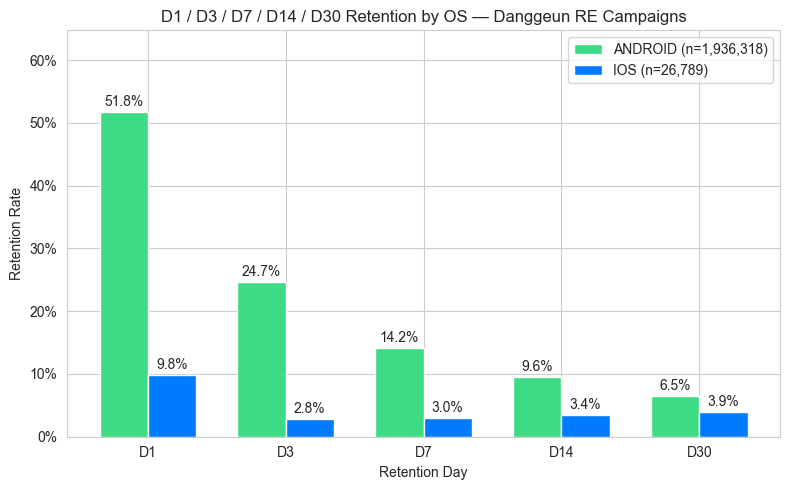

In [42]:
#@title Step 3: Summary table & bar chart

summary = df_ret.groupby('os').agg(
    cohort_size=('mtid', 'nunique'),
    ret_d1=('ret_d1', 'sum'),
    ret_d3=('ret_d3', 'sum'),
    ret_d7=('ret_d7', 'sum'),
    ret_d14=('ret_d14', 'sum'),
    ret_d30=('ret_d30', 'sum'),
).reset_index()

for d in RETENTION_DAYS:
    summary[f'retention_d{d}'] = summary[f'ret_d{d}'] / summary['cohort_size']

print('=== Overall Retention by OS ===')
display_cols = ['os', 'cohort_size'] + [f'ret_d{d}' for d in RETENTION_DAYS] + [f'retention_d{d}' for d in RETENTION_DAYS]
print(summary[display_cols].to_string(index=False, float_format='{:.4f}'.format))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(RETENTION_DAYS))
width = 0.35
os_list = summary['os'].unique()

for i, os_val in enumerate(os_list):
    row = summary[summary['os'] == os_val].iloc[0]
    rates = [row[f'retention_d{d}'] for d in RETENTION_DAYS]
    bars = ax.bar(x + i * width - width / 2, rates, width,
                  label=f"{os_val} (n={int(row['cohort_size']):,})",
                  color=OS_COLORS.get(os_val, OS_COLORS.get(os_val.lower(), 'gray')))
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{rate:.1%}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Retention Day')
ax.set_ylabel('Retention Rate')
ax.set_title('D1 / D3 / D7 / D14 / D30 Retention by OS — Danggeun RE Campaigns')
ax.set_xticks(x)
ax.set_xticklabels([f'D{d}' for d in RETENTION_DAYS])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
ax.set_ylim(0, max(summary[[f'retention_d{d}' for d in RETENTION_DAYS]].max()) * 1.25)
plt.tight_layout()
plt.show()

---
## Step 4: Retention Curve D0–D7 <a id='step-4'></a>

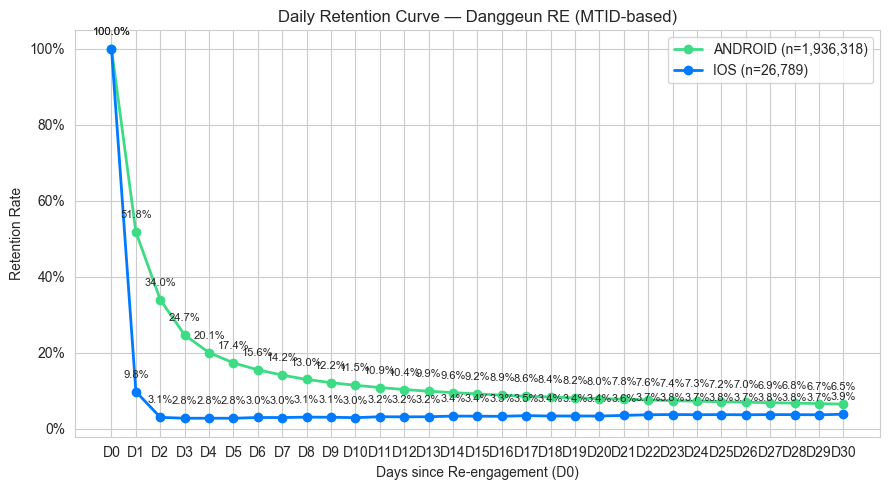

In [43]:
#@title Step 4: Daily retention curve

fig, ax = plt.subplots(figsize=(9, 5))

for os_val in df_curve['os'].unique():
    subset = df_curve[df_curve['os'] == os_val].sort_values('day_n')
    n = subset['cohort_size'].iloc[0]
    ax.plot(subset['day_n'], subset['retention_rate'],
            marker='o', linewidth=2,
            label=f'{os_val} (n={n:,})',
            color=OS_COLORS.get(os_val, OS_COLORS.get(os_val.lower(), 'gray')))
    for _, row in subset.iterrows():
        ax.annotate(f"{row['retention_rate']:.1%}",
                    (row['day_n'], row['retention_rate']),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=8)

ax.set_xlabel('Days since Re-engagement (D0)')
ax.set_ylabel('Retention Rate')
ax.set_title('Daily Retention Curve — Danggeun RE (MTID-based)')
ax.set_xticks(range(31))
ax.set_xticklabels([f'D{i}' for i in range(31)])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 5: Cohort Trend (Weekly) <a id='step-5'></a>

Do retention rates improve or degrade over time? Group re-engagement dates into weekly cohorts.

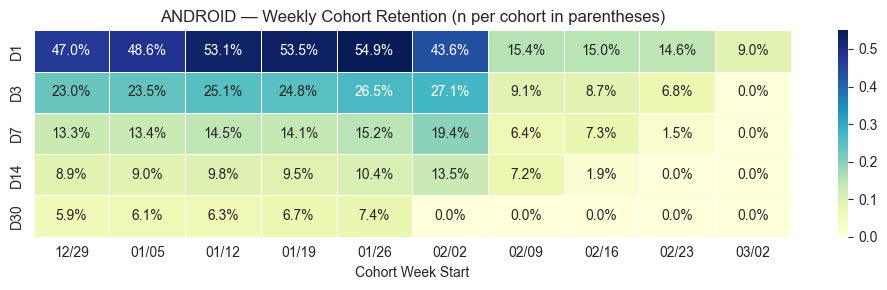


ANDROID weekly cohort sizes:
week_label  cohort_size
     12/29       237704
     01/05       405644
     01/12       426751
     01/19       433109
     01/26       423730
     02/02         5458
     02/09         1450
     02/16         1257
     02/23          981
     03/02          234



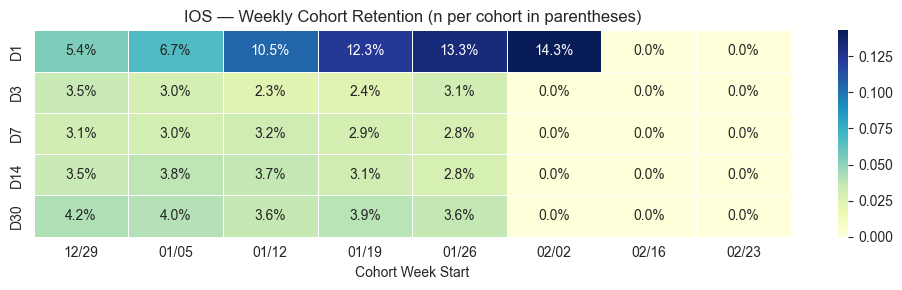


IOS weekly cohort sizes:
week_label  cohort_size
     12/29         3930
     01/05         6128
     01/12         5776
     01/19         5501
     01/26         5445
     02/02            7
     02/16            1
     02/23            1



In [44]:
#@title Step 5: Weekly cohort heatmap

df_ret['cohort_week'] = pd.to_datetime(df_ret['reengage_date']).dt.to_period('W').apply(lambda r: r.start_time)

cohort_data = df_ret.groupby(['os', 'cohort_week']).agg(
    cohort_size=('mtid', 'nunique'),
    ret_d1=('ret_d1', 'sum'),
    ret_d3=('ret_d3', 'sum'),
    ret_d7=('ret_d7', 'sum'),
    ret_d14=('ret_d14', 'sum'),
    ret_d30=('ret_d30', 'sum'),
).reset_index()

for d in RETENTION_DAYS:
    cohort_data[f'rate_d{d}'] = (cohort_data[f'ret_d{d}'] / cohort_data['cohort_size']).astype(float)

for os_val in cohort_data['os'].unique():
    subset = cohort_data[cohort_data['os'] == os_val].copy()
    if len(subset) < 2:
        print(f'{os_val}: Not enough weekly cohorts for heatmap (n={len(subset)})')
        continue

    subset['week_label'] = subset['cohort_week'].dt.strftime('%m/%d')
    pivot = subset.set_index('week_label')[[f'rate_d{d}' for d in RETENTION_DAYS]].T
    pivot.index = [f'D{d}' for d in RETENTION_DAYS]

    fig, ax = plt.subplots(figsize=(max(10, len(subset) * 0.8), 3))
    sns.heatmap(pivot, annot=True, fmt='.1%', cmap='YlGnBu', ax=ax,
                linewidths=0.5, vmin=0)
    ax.set_title(f'{os_val} — Weekly Cohort Retention (n per cohort in parentheses)')
    ax.set_xlabel('Cohort Week Start')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

    print(f'\n{os_val} weekly cohort sizes:')
    print(subset[['week_label', 'cohort_size']].to_string(index=False))
    print()

---
## Step 6: Event Breakdown <a id='step-6'></a>

Which postback events appear in the retention window? Helps understand the *quality* of re-engaged users.

In [45]:
#@title Step 6: Event breakdown query

query_events = f'''
WITH
  campaigns AS (
    SELECT cd.campaign_id, cd.campaign_os AS os
    FROM `focal-elf-631.standard_digest.campaign_digest` cd
    WHERE cd.campaign_id IN ({campaign_id_list})
  ),

  re_events AS (
    SELECT
      cv.bid.mtid AS mtid,
      DATE(cv.timestamp) AS event_date,
      DATE(cv.imp.happened_at) AS imp_date,
      cv.cv.event_pb AS event_pb,
      cv.cv.pb.attribution.reengagement AS is_reengagement,
      c.os
    FROM `focal-elf-631.prod_stream_view.cv` cv
    JOIN campaigns c ON cv.api.campaign.id = c.campaign_id
    WHERE DATE(cv.timestamp) BETWEEN '{START_DATE}' AND DATE_ADD('{END_DATE}', INTERVAL 37 DAY)
      AND DATE(cv.imp.happened_at) BETWEEN '{START_DATE}' AND '{END_DATE}'
      AND cv.bid.mtid IS NOT NULL AND cv.bid.mtid != ''
  ),

  cohort AS (
    SELECT mtid, os, MIN(event_date) AS reengage_date
    FROM re_events
    WHERE is_reengagement = TRUE
      AND imp_date BETWEEN '{START_DATE}' AND '{END_DATE}'
    GROUP BY 1, 2
  )

SELECT
  c.os,
  re.event_pb,
  CASE
    WHEN DATE_DIFF(re.event_date, c.reengage_date, DAY) = 0 THEN 'D0'
    WHEN DATE_DIFF(re.event_date, c.reengage_date, DAY) BETWEEN 1 AND 1 THEN 'D1'
    WHEN DATE_DIFF(re.event_date, c.reengage_date, DAY) BETWEEN 2 AND 3 THEN 'D2-3'
    WHEN DATE_DIFF(re.event_date, c.reengage_date, DAY) BETWEEN 4 AND 7 THEN 'D4-7'
    WHEN DATE_DIFF(re.event_date, c.reengage_date, DAY) BETWEEN 8 AND 14 THEN 'D8-14'
    WHEN DATE_DIFF(re.event_date, c.reengage_date, DAY) BETWEEN 15 AND 30 THEN 'D15-30'
  END AS day_bucket,
  COUNT(1) AS event_count,
  COUNT(DISTINCT c.mtid) AS unique_users
FROM cohort c
JOIN re_events re ON c.mtid = re.mtid
  AND re.event_date BETWEEN c.reengage_date AND DATE_ADD(c.reengage_date, INTERVAL 30 DAY)
GROUP BY 1, 2, 3
ORDER BY 1, 3, 4 DESC
'''

print('Running event breakdown query...')
df_events = process_query(query_events)
print(f'Rows: {len(df_events)}')

for os_val in df_events['os'].unique():
    print(f'\n=== {os_val} — Top Events by Day Bucket ===')
    subset = df_events[df_events['os'] == os_val]
    for bucket in ['D0', 'D1', 'D2-3', 'D4-7', 'D8-14', 'D15-30']:
        b_data = subset[subset['day_bucket'] == bucket].nlargest(10, 'event_count')
        if len(b_data) > 0:
            print(f'\n  {bucket}:')
            print(b_data[['event_pb', 'event_count', 'unique_users']].to_string(index=False))

Running event breakdown query...
Rows: 1021

=== ANDROID — Top Events by Day Bucket ===

  D0:
                    event_pb  event_count  unique_users
        show_fleamarket_feed     11970648       1401284
                show_article      8168837        573407
                reengagement      1934684       1934601
 completed_common_checkIn_v1      1393575        646331
              event_check_in      1117510        522581
   show_jobs_job_post_detail       770850        201529
  show_realty_article_detail       542729        129020
show_localbiz_pedometer_home       452135        150251
          show_ad_adsmanager       419682        304832
         click_article_watch       338443         99750

  D1:
                    event_pb  event_count  unique_users
        show_fleamarket_feed     17760355        936772
                show_article     13237600        638269
 completed_common_checkIn_v1      1927845        580382
              event_check_in      1489778        454097
  

---
## Step 7: Summary & Insights <a id='step-7'></a>

In [46]:
#@title Step 7: Summary

print('=' * 80)
print('DANGGEUN RE RETENTION ANALYSIS — SUMMARY')
print('=' * 80)
print(f'\nDate range: {START_DATE} → {END_DATE}')
print(f'Advertiser ID: {ADVERTISER_ID}')
print(f'Campaigns analyzed: {len(campaign_ids)}')
print(f'User identifier: MTID (covers LAT users on iOS)')
print(f'\n--- Overall Retention by OS ---')
for _, row in summary.iterrows():
    print(f"  {row['os']:10s}  n={int(row['cohort_size']):>8,}  "
          f"D1={row['retention_d1']:.2%}  D3={row['retention_d3']:.2%}  D7={row['retention_d7']:.2%}  D14={row['retention_d14']:.2%}  D30={row['retention_d30']:.2%}")

print(f'\n--- Key Observations ---')
print('  [TODO: Fill in after running with real data]')
print('  1. iOS vs Android retention gap: ...')
print('  2. Retention trend over cohort weeks: ...')
print('  3. Dominant post-RE events: ...')

print(f'\n--- Caveats ---')
print('  • iOS RE is LAT-only (no IDFA campaigns); Android serves as the baseline.')
print('  • Retention measured from Moloco-attributed events only (cv table).')
print('  • Organic returns not captured — true retention likely higher.')
print('  • D0 = first RE-attributed event per MTID; multi-day RE users assigned to earliest cohort.')
print('=' * 80)

DANGGEUN RE RETENTION ANALYSIS — SUMMARY

Date range: 2026-01-01 → 2026-02-01
Advertiser ID: Voql38wJkmDNzXbW
Campaigns analyzed: 6
User identifier: MTID (covers LAT users on iOS)

--- Overall Retention by OS ---
  ANDROID     n=1,936,318  D1=51.80%  D3=24.71%  D7=14.17%  D14=9.57%  D30=6.51%
  IOS         n=  26,789  D1=9.82%  D3=2.82%  D7=3.00%  D14=3.39%  D30=3.86%

--- Key Observations ---
  [TODO: Fill in after running with real data]
  1. iOS vs Android retention gap: ...
  2. Retention trend over cohort weeks: ...
  3. Dominant post-RE events: ...

--- Caveats ---
  • iOS RE is LAT-only (no IDFA campaigns); Android serves as the baseline.
  • Retention measured from Moloco-attributed events only (cv table).
  • Organic returns not captured — true retention likely higher.
  • D0 = first RE-attributed event per MTID; multi-day RE users assigned to earliest cohort.


In [ ]:
#@title (Optional) Export results to Excel

import os

output_dir = os.path.dirname(os.path.abspath('__file__'))
output_path = os.path.join(output_dir, 'RE_LAT_Danggeun_Retention_Results.xlsx')

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    summary.to_excel(writer, sheet_name='Retention by OS', index=False)
    df_curve.to_excel(writer, sheet_name='Daily Curve D0-30', index=False)
    df_ret.to_excel(writer, sheet_name='Raw Cohort Data', index=False)
    if 'df_events' in dir():
        df_events.to_excel(writer, sheet_name='Event Breakdown', index=False)

print(f'Exported to {output_path}')

ValueError: This sheet is too large! Your sheet size is: 1963107, 11 Max sheet size is: 1048576, 16384

In [47]:
# end of notebook